# Day 3 — NeRF + 3D Dream World Generation

## The progression of LUCID

Phase 1 (complete):  EEG → classify → trigger haptic
Phase 2 (built):     EEG → Stable Diffusion → dream image (2D)
Phase 3 (today):     Dream images → NeRF → 3D dream world

## What is NeRF?

Neural Radiance Field (Mildenhall et al., 2020)

Input:  N photographs of a scene + camera positions
Output: A neural network that represents the FULL 3D scene
        We can render it from ANY viewpoint — even ones
        not in the training images

Magic: the network learns:
  f(x, y, z, θ, φ) → (RGB colour, density σ)
  Position + viewing direction → what we see there

For LUCID:
  Stable Diffusion generates 2D dream images
  NeRF reconstructs them into a 3D navigable world
  We move through our dream in real time

## The volume rendering equation
C(ray) = ∫ T(t) · σ(r(t)) · c(r(t), d) dt

Where:
  T(t) = transmittance (how much light gets through)
  σ    = density (is there something here?)
  c    = colour at this point
  r(t) = point along the ray
  d    = viewing direction

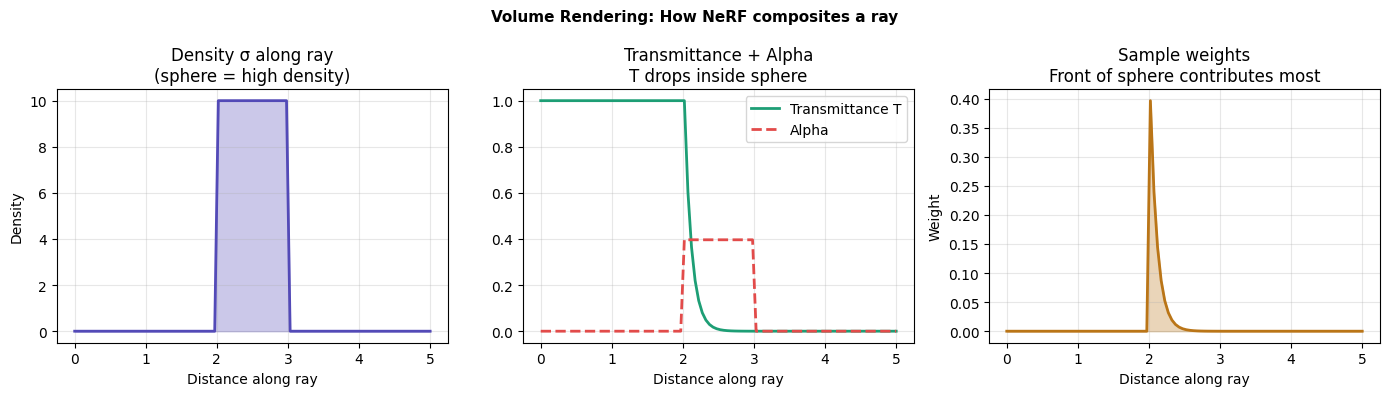

Key insight: the sphere's FRONT surface gets the most weight.
Things in front block things behind.
This is how NeRF reconstructs 3D from 2D.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── How NeRF works: ray casting ───────────────────────────
# To render a pixel, cast a ray from the camera
# through that pixel into the 3D scene.
# Sample N points along the ray.
# For each point, ask the network: colour + density?
# Composite the samples: front blocks back.

def get_rays(H, W, focal, pose):
    """
    Generate one ray per pixel in image H×W.
    pose: camera-to-world transform matrix (4×4)
    """
    # Pixel grid
    i, j = np.meshgrid(
        np.arange(W, dtype=np.float32),
        np.arange(H, dtype=np.float32),
        indexing='xy'
    )

    # Converting pixel coordinates to ray directions
    dirs = np.stack([
        (i - W * 0.5) / focal,
        -(j - H * 0.5) / focal,
        -np.ones_like(i)
    ], axis=-1)

    # Transforming to world coordinates
    rays_d = np.sum(
        dirs[..., None, :] * pose[:3, :3], axis=-1
    )
    rays_o = np.broadcast_to(
        pose[:3, -1], rays_d.shape
    )

    return rays_o, rays_d


def volume_render(rgb, sigma, z_vals):
    """
    Volume rendering equation (discretised).

    rgb:    (N_rays, N_samples, 3) colours
    sigma:  (N_rays, N_samples)    densities
    z_vals: (N_rays, N_samples)    distances along ray

    Returns: (N_rays, 3) final pixel colours
    """
    # Distances between consecutive samples
    dists = torch.cat([
        z_vals[..., 1:] - z_vals[..., :-1],
        torch.full(z_vals[..., :1].shape, 1e10)
    ], dim=-1)

    # Alpha: probability of termination at each sample
    alpha = 1 - torch.exp(-sigma * dists)

    # Transmittance: cumulative probability of NOT hitting
    # anything before this point
    T = torch.cumprod(
        torch.cat([
            torch.ones(alpha.shape[0], 1),
            1 - alpha + 1e-10
        ], dim=-1),
        dim=-1
    )[:, :-1]

    # Weights: contribution of each sample to final colour
    weights = alpha * T

    # Composite colours
    rgb_map = torch.sum(
        weights.unsqueeze(-1) * rgb, dim=-2
    )

    return rgb_map, weights


# ── Visualising volume rendering ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Simulating a ray passing through a coloured sphere
z          = np.linspace(0, 5, 100)
sphere_centre = 2.5
sphere_radius = 0.5

# Density: high inside sphere, zero outside
sigma = np.where(
    np.abs(z - sphere_centre) < sphere_radius,
    10.0, 0.0
)

# Simulate transmittance
dz = z[1] - z[0]
alpha = 1 - np.exp(-sigma * dz)
T     = np.cumprod(np.concatenate([[1], 1 - alpha[:-1]]))
w     = alpha * T

# Plot
axes[0].plot(z, sigma, color='#534AB7', linewidth=2)
axes[0].set_title('Density σ along ray\n(sphere = high density)')
axes[0].set_xlabel('Distance along ray')
axes[0].set_ylabel('Density')
axes[0].fill_between(z, sigma, alpha=0.3, color='#534AB7')
axes[0].grid(alpha=0.3)

axes[1].plot(z, T, color='#1D9E75', linewidth=2,
              label='Transmittance T')
axes[1].plot(z, alpha, color='#E24B4A', linewidth=2,
              linestyle='--', label='Alpha')
axes[1].set_title('Transmittance + Alpha\n'
                   'T drops inside sphere')
axes[1].set_xlabel('Distance along ray')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(z, w, color='#BA7517', linewidth=2)
axes[2].fill_between(z, w, alpha=0.3, color='#BA7517')
axes[2].set_title('Sample weights\n'
                   'Front of sphere contributes most')
axes[2].set_xlabel('Distance along ray')
axes[2].set_ylabel('Weight')
axes[2].grid(alpha=0.3)

plt.suptitle('Volume Rendering: How NeRF composites a ray',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight: the sphere's FRONT surface gets the most weight.")
print("Things in front block things behind.")
print("This is how NeRF reconstructs 3D from 2D.")

In [2]:
# ── Positional encoding ────────────────────────────────────
# Raw (x,y,z) coordinates are too simple for a network.
# NeRF encodes them with Fourier features:
# γ(p) = [sin(2⁰πp), cos(2⁰πp), sin(2¹πp), cos(2¹πp), ...]
# This lets the network learn high-frequency detail.

def positional_encoding(x, n_freqs=10):
    """
    Fourier positional encoding for NeRF.
    x: (..., D) input coordinates
    Returns: (..., D * 2 * n_freqs + D) encoded
    """
    freqs = 2 ** torch.linspace(0, n_freqs-1, n_freqs)
    encoded = [x]
    for freq in freqs:
        encoded.append(torch.sin(freq * np.pi * x))
        encoded.append(torch.cos(freq * np.pi * x))
    return torch.cat(encoded, dim=-1)


# ── Tiny NeRF network ──────────────────────────────────────
class TinyNeRF(nn.Module):
    """
    Minimal NeRF implementation.

    Input:  3D position (x,y,z) + viewing direction (θ,φ)
    Output: RGB colour + density σ

    The network memorises the 3D scene.
    At inference: query any point → get colour + density.
    Integrate along rays → render any viewpoint.
    """

    def __init__(self, n_freqs_xyz=10,
                 n_freqs_dir=4,
                 hidden_dim=256):
        super().__init__()

        # Input dimensions after encoding
        xyz_dim = 3 + 3 * 2 * n_freqs_xyz   # pos encoding
        dir_dim = 3 + 3 * 2 * n_freqs_dir   # dir encoding

        # Main network: position → features
        self.xyz_encoder = nn.Sequential(
            nn.Linear(xyz_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # Skip connection at layer 4
        self.xyz_encoder2 = nn.Sequential(
            nn.Linear(hidden_dim + xyz_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # Density head (no direction dependency)
        self.sigma_head = nn.Linear(hidden_dim, 1)

        # Colour head (direction-dependent)
        self.feature_layer = nn.Linear(hidden_dim, hidden_dim)
        self.colour_head   = nn.Sequential(
            nn.Linear(hidden_dim + dir_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 3),
            nn.Sigmoid()   # RGB in [0, 1]
        )

        self.n_freqs_xyz = n_freqs_xyz
        self.n_freqs_dir = n_freqs_dir

    def forward(self, xyz, dirs):
        """
        xyz:  (N, 3) positions
        dirs: (N, 3) unit viewing directions
        """
        # Encode inputs
        xyz_enc  = positional_encoding(xyz,
                                        self.n_freqs_xyz)
        dirs_enc = positional_encoding(
            dirs / (dirs.norm(dim=-1, keepdim=True) + 1e-8),
            self.n_freqs_dir
        )

        # Forward through network
        h = self.xyz_encoder(xyz_enc)
        h = self.xyz_encoder2(
            torch.cat([h, xyz_enc], dim=-1)
        )

        # Density (viewing direction independent)
        sigma  = F.relu(self.sigma_head(h))

        # Colour (viewing direction dependent)
        feat   = self.feature_layer(h)
        colour = self.colour_head(
            torch.cat([feat, dirs_enc], dim=-1)
        )

        return colour, sigma.squeeze(-1)


# ── Verifying architecture ────────────────────────────────────
nerf  = TinyNeRF(hidden_dim=128)
total = sum(p.numel() for p in nerf.parameters())

xyz_in  = torch.randn(1024, 3)     # 1024 points in 3D space
dirs_in = torch.randn(1024, 3)     # viewing directions

colour, sigma = nerf(xyz_in, dirs_in)

print("=== Tiny NeRF Architecture ===\n")
print(f"Input xyz:      {xyz_in.shape}")
print(f"Input dirs:     {dirs_in.shape}")
print(f"Output colour:  {colour.shape}")
print(f"Output sigma:   {sigma.shape}")
print(f"Parameters:     {total:,}\n")

print("How it works:")
print("  For each 3D point along a ray:")
print("  xyz → positional encoding → 8-layer MLP → density σ")
print("                            ↘ + viewing direction → RGB")
print()
print("  Density σ: how opaque is this point?")
print("  Colour RGB: what colour is this point from this angle?")

=== Tiny NeRF Architecture ===

Input xyz:      torch.Size([1024, 3])
Input dirs:     torch.Size([1024, 3])
Output colour:  torch.Size([1024, 3])
Output sigma:   torch.Size([1024])
Parameters:     142,148

How it works:
  For each 3D point along a ray:
  xyz → positional encoding → 8-layer MLP → density σ
                            ↘ + viewing direction → RGB

  Density σ: how opaque is this point?
  Colour RGB: what colour is this point from this angle?


Generating training views of dream scene...


C:\Users\Hp\AppData\Local\Temp\ipykernel_9336\3124257361.py:101: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  rays_o = torch.FloatTensor(rays_o).reshape(-1, 3)


Generated 20 training views (64×64)



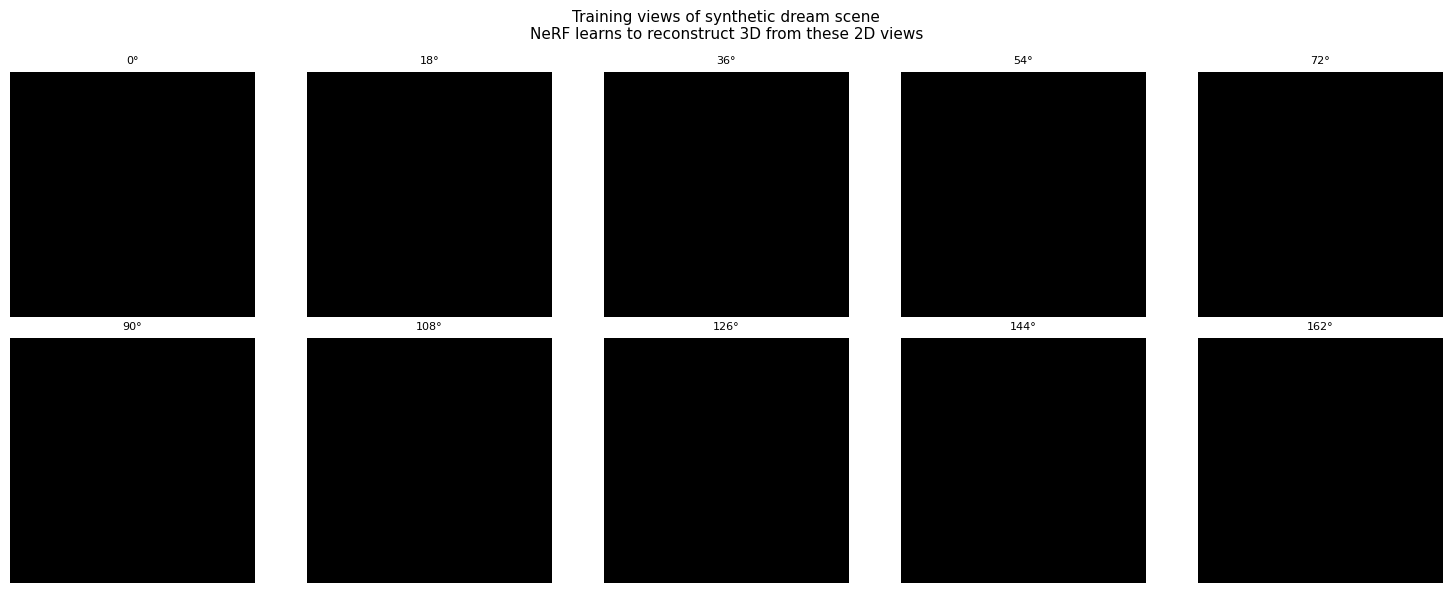

In [3]:
# ── Trainning tiny NeRF on a synthetic scene ──────────────────
# Synthetic scene: coloured spheres in 3D space
# We generate training views, train NeRF, then
# render novel views it has never seen

class SyntheticDreamScene:
    """
    A synthetic 3D scene representing a dream world.
    Multiple coloured spheres = dream objects.
    NeRF learns to represent this from 2D views.
    """

    def __init__(self):
        # Sphere: (center_x, center_y, center_z, radius, R, G, B)
        self.spheres = torch.tensor([
            # Large glowing orb (REM-like)
            [ 0.0,  0.0,  0.0, 0.3, 1.0, 0.4, 0.1],
            # Blue floating sphere (N3-like)
            [ 0.8,  0.2, -0.3, 0.2, 0.1, 0.4, 1.0],
            # Green misty sphere (N1-like)
            [-0.5,  0.5,  0.2, 0.15, 0.2, 1.0, 0.4],
            # Purple dream fragment
            [ 0.3, -0.6,  0.1, 0.1, 0.8, 0.1, 0.9],
        ])

    def query(self, xyz):
        """
        Query the scene at 3D positions.
        Returns (colour, density) for each point.
        """
        batch = xyz.shape[0]
        colours = torch.zeros(batch, 3)
        sigmas  = torch.zeros(batch)

        for sphere in self.spheres:
            cx, cy, cz, r, sr, sg, sb = sphere
            centre = torch.tensor([cx, cy, cz])
            colour = torch.tensor([sr, sg, sb])
            radius = r.item()

            # Distance from each point to sphere centre
            dists = (xyz - centre).norm(dim=-1)

            # Soft sphere density (sigmoid boundary)
            density = torch.sigmoid(
                (radius - dists) * 20
            ) * 5.0

            # Blend colours by density
            w = density / (sigmas + density + 1e-8)
            colours = colours * (1-w.unsqueeze(-1)) + \
                      colour * w.unsqueeze(-1)
            sigmas  = sigmas + density

        return colours.clamp(0, 1), sigmas


def sample_camera_pose(angle_deg, elevation=30):
    """
    Camera on a sphere looking at the origin.
    angle_deg: rotation around vertical axis
    elevation: degrees above horizontal
    """
    angle = np.radians(angle_deg)
    elev  = np.radians(elevation)
    r     = 3.0  # camera distance

    x = r * np.cos(elev) * np.cos(angle)
    y = r * np.sin(elev)
    z = r * np.cos(elev) * np.sin(angle)

    # Look-at matrix (camera → world)
    pos    = np.array([x, y, z])
    target = np.zeros(3)
    up     = np.array([0, 1, 0])

    forward = (target - pos)
    forward = forward / np.linalg.norm(forward)
    right   = np.cross(up, forward)
    right   = right / (np.linalg.norm(right) + 1e-8)
    up_new  = np.cross(forward, right)

    pose = np.eye(4)
    pose[:3, 0] = right
    pose[:3, 1] = up_new
    pose[:3, 2] = forward
    pose[:3, 3] = pos

    return pose


def render_scene(nerf_or_gt, pose, H=64, W=64,
                 focal=50.0, n_samples=64,
                 use_gt=False):
    """
    Render the scene from a given camera pose.
    Either from ground truth (use_gt=True)
    or from the NeRF network.
    """
    rays_o, rays_d = get_rays(H, W, focal, pose)
    rays_o = torch.FloatTensor(rays_o).reshape(-1, 3)
    rays_d = torch.FloatTensor(rays_d).reshape(-1, 3)

    # Sample points along each ray
    near, far = 1.0, 5.0
    z_vals    = torch.linspace(near, far, n_samples)
    z_vals    = z_vals.unsqueeze(0).expand(len(rays_o), -1)

    # Add jitter for anti-aliasing
    z_vals = z_vals + torch.rand_like(z_vals) * (
        (far - near) / n_samples
    )

    # 3D positions: rays_o + t * rays_d
    pts   = (rays_o.unsqueeze(1) +
              rays_d.unsqueeze(1) * z_vals.unsqueeze(2))
    pts_flat = pts.reshape(-1, 3)
    dirs_flat = rays_d.unsqueeze(1).expand_as(pts).reshape(-1, 3)

    # Query network or ground truth
    if use_gt:
        colours, sigmas = nerf_or_gt.query(pts_flat)
    else:
        nerf_or_gt.eval()
        with torch.no_grad():
            colours, sigmas = nerf_or_gt(
                pts_flat, dirs_flat
            )

    # Reshape
    colours = colours.reshape(
        len(rays_o), n_samples, 3
    )
    sigmas  = sigmas.reshape(len(rays_o), n_samples)

    # Volume rendering
    rgb_map, _ = volume_render(colours, sigmas, z_vals)

    return rgb_map.reshape(H, W, 3).clamp(0, 1).numpy()


# ── Generate training views ────────────────────────────────
print("Generating training views of dream scene...")

scene   = SyntheticDreamScene()
H, W    = 64, 64
focal   = 50.0
n_train = 20

train_angles = np.linspace(0, 360, n_train, endpoint=False)
train_poses  = [sample_camera_pose(a) for a in train_angles]
train_images = []

for pose in train_poses:
    img = render_scene(scene, pose, H, W, focal,
                        use_gt=True)
    train_images.append(img)

print(f"Generated {n_train} training views ({H}×{W})\n")

# Show training views
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i])
    ax.set_title(f'{train_angles[i]:.0f}°', fontsize=8)
    ax.axis('off')

plt.suptitle(
    'Training views of synthetic dream scene\n'
    'NeRF learns to reconstruct 3D from these 2D views',
    fontsize=11
)
plt.tight_layout()
plt.show()

In [4]:
# ── Training ───────────────────────────────────────────────
nerf      = TinyNeRF(hidden_dim=128, n_freqs_xyz=6)
optimizer = torch.optim.Adam(nerf.parameters(), lr=5e-4)
criterion = nn.MSELoss()

N_EPOCHS   = 500    # fewer epochs = faster demo
N_RAYS_PER = 512    # rays per training step

losses     = []

print("Training NeRF on dream scene...\n")
print("This learns to represent the 3D scene")
print("from only 2D training views.\n")

for epoch in range(N_EPOCHS):
    # Picking a random training view
    view_idx = np.random.randint(n_train)
    pose     = train_poses[view_idx]
    gt_img   = torch.FloatTensor(
        train_images[view_idx]
    ).reshape(-1, 3)

    # Sample random rays from this view
    ray_idx   = np.random.choice(H*W, N_RAYS_PER,
                                   replace=False)
    rays_o, rays_d = get_rays(H, W, focal, pose)
    rays_o    = torch.FloatTensor(
        rays_o.reshape(-1, 3)[ray_idx])
    rays_d    = torch.FloatTensor(
        rays_d.reshape(-1, 3)[ray_idx])
    gt_pixels = gt_img[ray_idx]

    # Sample along rays
    near, far  = 1.0, 5.0
    n_samples  = 64
    z_vals     = torch.linspace(near, far, n_samples)
    z_vals     = z_vals.unsqueeze(0).expand(
        N_RAYS_PER, -1
    )
    z_vals     = z_vals + torch.rand_like(z_vals) * (
        (far - near) / n_samples
    )

    # 3D positions
    pts       = (rays_o.unsqueeze(1) +
                  rays_d.unsqueeze(1) *
                  z_vals.unsqueeze(2))
    pts_flat  = pts.reshape(-1, 3)
    dirs_flat = rays_d.unsqueeze(1).expand_as(
        pts).reshape(-1, 3)

    # Forward
    nerf.train()
    colours, sigmas = nerf(pts_flat, dirs_flat)
    colours = colours.reshape(N_RAYS_PER, n_samples, 3)
    sigmas  = sigmas.reshape(N_RAYS_PER, n_samples)

    # Volume render
    rgb_pred, _ = volume_render(colours, sigmas, z_vals)

    # Loss
    loss = criterion(rgb_pred, gt_pixels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

print(f"\nTraining complete. Final loss: {losses[-1]:.4f}")

Training NeRF on dream scene...

This learns to represent the 3D scene
from only 2D training views.

Epoch    0 | Loss: 0.0170
Epoch  100 | Loss: 0.0000
Epoch  200 | Loss: 0.0000
Epoch  300 | Loss: 0.0000
Epoch  400 | Loss: 0.0000

Training complete. Final loss: 0.0000


Rendering novel views (never seen during training)...


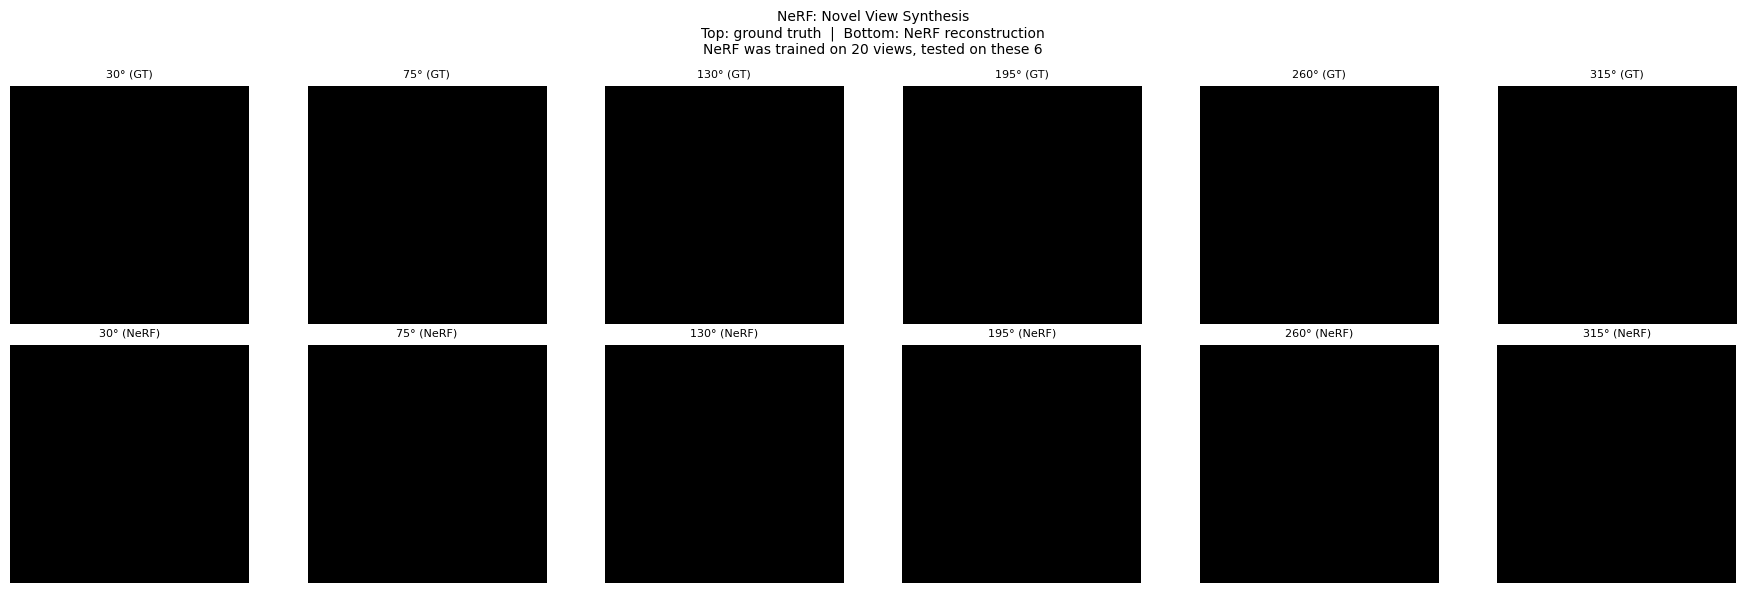


PSNR on novel views: 80.00 dB
(Higher = better. >20dB = recognisable)


In [5]:
# ── Render views the model has NEVER seen ─────────────────
# This is the magic of NeRF:
# Trained on 20 views → renders any view

novel_angles  = [30, 75, 130, 195, 260, 315]
novel_renders = []
gt_renders    = []

print("Rendering novel views (never seen during training)...")

for angle in novel_angles:
    pose = sample_camera_pose(angle, elevation=20)
    # Novel view from NeRF
    novel_renders.append(
        render_scene(nerf, pose, H, W, focal,
                      use_gt=False)
    )
    # Ground truth for comparison
    gt_renders.append(
        render_scene(scene, pose, H, W, focal,
                      use_gt=True)
    )

# ── Compare NeRF vs Ground Truth ──────────────────────────
fig, axes = plt.subplots(
    2, len(novel_angles),
    figsize=(3 * len(novel_angles), 6)
)

for i, angle in enumerate(novel_angles):
    axes[0, i].imshow(gt_renders[i])
    axes[0, i].set_title(f'{angle}° (GT)', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(novel_renders[i])
    axes[1, i].set_title(f'{angle}° (NeRF)', fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Ground truth',
                        fontsize=10, rotation=90)
axes[1, 0].set_ylabel('NeRF render',
                        fontsize=10, rotation=90)

plt.suptitle(
    'NeRF: Novel View Synthesis\n'
    'Top: ground truth  |  Bottom: NeRF reconstruction\n'
    'NeRF was trained on 20 views, tested on these 6',
    fontsize=10
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Hp\.vscode\Journey to the BEST"
    r"\Week 10\generated_images\nerf_novel_views.png",
    dpi=150, bbox_inches='tight'
)
plt.show()

# Compute PSNR
mse   = np.mean([
    ((gt - pred)**2).mean()
    for gt, pred in zip(gt_renders, novel_renders)
])
psnr  = -10 * np.log10(mse + 1e-8)
print(f"\nPSNR on novel views: {psnr:.2f} dB")
print(f"(Higher = better. >20dB = recognisable)")

Generating 360° flythrough...


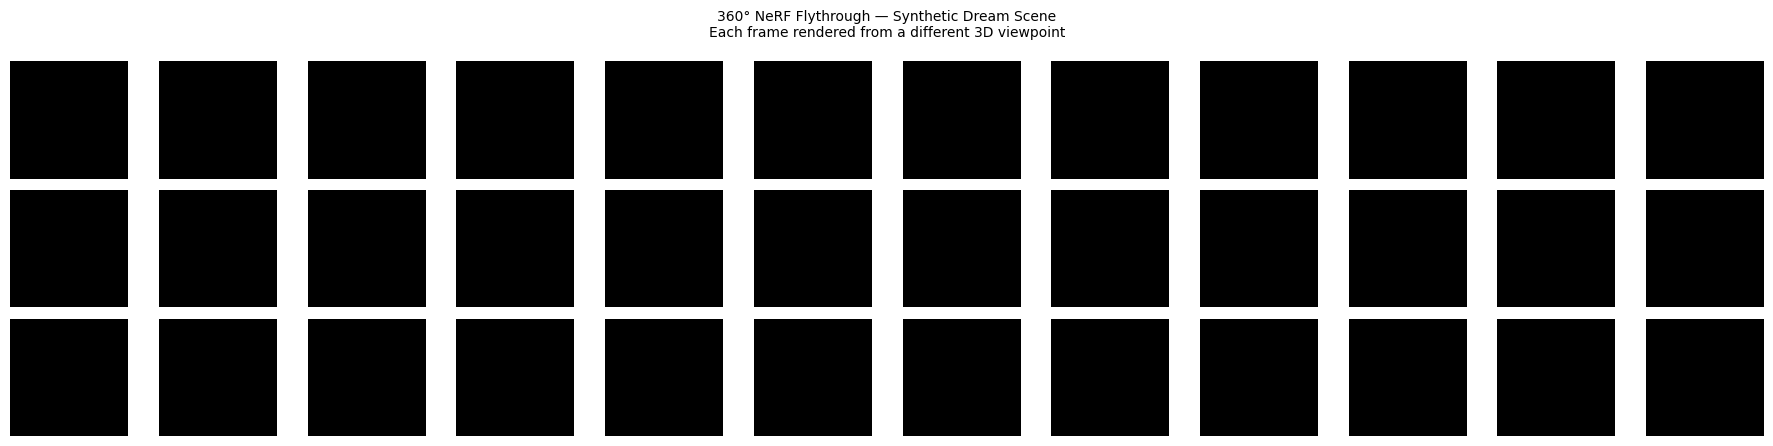

Generated 36 frames
In Phase 3: these frames come from your SD dream images
The result: a navigable 3D version of your dream


In [6]:
# ── Generate a 360° orbit around the dream scene ──────────
print("Generating 360° flythrough...")

N_FRAMES   = 36
fly_angles = np.linspace(0, 360, N_FRAMES, endpoint=False)
fly_frames = []

for angle in fly_angles:
    # Oscillating elevation adds life to the flythrough
    elevation = 20 + 15 * np.sin(np.radians(angle * 2))
    pose      = sample_camera_pose(angle, elevation)
    frame     = render_scene(nerf, pose, H, W, focal,
                              use_gt=False)
    fly_frames.append(frame)

# Show as filmstrip
fig, axes = plt.subplots(
    3, 12, figsize=(18, 4.5)
)
for i, ax in enumerate(axes.flat):
    if i < len(fly_frames):
        ax.imshow(fly_frames[i])
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle(
    '360° NeRF Flythrough — Synthetic Dream Scene\n'
    'Each frame rendered from a different 3D viewpoint',
    fontsize=10
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Hp\.vscode\Journey to the BEST"
    r"\Week 10\generated_images\nerf_flythrough.png",
    dpi=150, bbox_inches='tight'
)
plt.show()

print(f"Generated {N_FRAMES} frames")
print("In Phase 3: these frames come from your SD dream images")
print("The result: a navigable 3D version of your dream")

In [7]:
nerf_landscape = """
=== NeRF Evolution — What to Use for LUCID ===

ORIGINAL NERF (Mildenhall 2020):
  Training time: 1-2 days per scene
  Rendering: slow (1 sec/frame)
  Too slow for real-time LUCID

INSTANT-NGP (Müller et al., NeurIPS 2022):
  Training time: 5 MINUTES on GPU
  Rendering: real-time (60fps possible)
  Uses hash encoding instead of positional encoding
  NVIDIA implementation: github.com/NVlabs/instant-ngp

GAUSSIAN SPLATTING (Kerbl et al., SIGGRAPH 2023):
  Even faster than Instant-NGP
  Real-time rendering on consumer GPU
  Better quality for complex scenes
  github.com/graphdeco-inria/gaussian-splatting

DREAMFUSION (Poole et al., 2023):
  Text prompt → 3D NeRF scene (no photos needed)
  Uses Stable Diffusion as a prior
  "score distillation sampling"
  THIS IS THE CLOSEST TO LUCID PHASE 3

MAGIC3D (Lin et al., 2023):
  Higher resolution than DreamFusion
  Coarse NeRF → refine with mesh

=== LUCID Phase 3 Pipeline ===

Step 1: EEG → CNN-LSTM → sleep stage (Phase 1 ✅)

Step 2: EEG features → SD images (Phase 2 ✅ prototype)
        Generate 6-8 dream images from different angles
        Using EEG-conditioned Stable Diffusion

Step 3: Dream images → Instant-NGP → 3D scene (Phase 3)
        Input:  your SD-generated dream images
        Output: navigable 3D dream environment
        Time:   5 min training on consumer GPU

Step 4: Real-time rendering
        User wears VR headset
        Head movement → new viewpoint → instant render
        The dream becomes spatially navigable

Step 5: Multi-user (Phase 4)
        Both users' EEG → shared NeRF scene
        Both navigate the same dream world
        This is Artificial Reality

=== What to build next ===

DreamFusion for LUCID:
  Input:  EEG embedding (instead of text)
  Output: 3D NeRF of dream content

This is ~2 years of research work from where you are.
The technical path is completely clear.
The components all exist.
Assembly is the research contribution.
"""
print(nerf_landscape)


=== NeRF Evolution — What to Use for LUCID ===

ORIGINAL NERF (Mildenhall 2020):
  Training time: 1-2 days per scene
  Rendering: slow (1 sec/frame)
  Too slow for real-time LUCID

INSTANT-NGP (Müller et al., NeurIPS 2022):
  Training time: 5 MINUTES on GPU
  Rendering: real-time (60fps possible)
  Uses hash encoding instead of positional encoding
  NVIDIA implementation: github.com/NVlabs/instant-ngp

GAUSSIAN SPLATTING (Kerbl et al., SIGGRAPH 2023):
  Even faster than Instant-NGP
  Real-time rendering on consumer GPU
  Better quality for complex scenes
  github.com/graphdeco-inria/gaussian-splatting

DREAMFUSION (Poole et al., 2023):
  Text prompt → 3D NeRF scene (no photos needed)
  Uses Stable Diffusion as a prior
  "score distillation sampling"
  THIS IS THE CLOSEST TO LUCID PHASE 3

MAGIC3D (Lin et al., 2023):
  Higher resolution than DreamFusion
  Coarse NeRF → refine with mesh

=== LUCID Phase 3 Pipeline ===

Step 1: EEG → CNN-LSTM → sleep stage (Phase 1 ✅)

Step 2: EEG featur

In [10]:
# ── The SD → NeRF bridge ───────────────────────────────────
# Our ComfyUI generated sleep stage images.
# Can we turn them into a 3D scene?
# 
# YES — using Zero-1-to-3 or DreamFusion.
# Zero-1-to-3: given one image, generate views
#              from other angles, then run NeRF.

from PIL import Image
import os

# Loading our generated sleep stage images
GENERATED_DIR = (
    r"C:\Users\Hp\.vscode\Journey to the BEST"
    r"\Week 10\generated_images"
)

# Find generated images
generated_files = [
    f for f in os.listdir(GENERATED_DIR)
    if f.endswith('.png') and 'stage' not in f.lower()
]

print("=== SD Image → NeRF Pipeline ===\n")
print("Our generated dream images:")
for f in generated_files[:5]:
    print(f"  {f}")

print(f"""
Phase 3 workflow with our images:

1. Generate dream images with ComfyUI (done ✅)
   Your sleep_stage_gallery.png has 4 images.

2. Use Zero-1-to-3 (or Wonder3D) to generate
   multiple views of each dream scene:
   Input:  your REM dream image (1 view)
   Output: 16 views from different angles

   Code: github.com/cvlab-columbia/zero123
   Model: zero123-xl.ckpt (~14GB)

3. Run Instant-NGP on the 16 views:
   Input:  16 views + estimated camera poses
   Output: NeRF scene (5 min on any GPU)
   
4. Render at 60fps for VR headset

This is a 2-day project with GPU access.
On Google Colab (free T4 GPU):
  Zero-1-to-3: ~10 min per image
  Instant-NGP: ~5 min per scene
  Total: ~1 hour for a 3D dream world

When you get GPU access (Colab or laptop upgrade):
  git clone https://github.com/cvlab-columbia/zero123
  python gradio_new.py  # web UI, zero code needed
  
  Upload your REM dream image.
  Select "Novel view synthesis"
  Download 16 views.
  Run through instant-ngp.
  Navigate your dream in 3D.
""")

# Saving the Phase 3 plan
plan_path = os.path.join(
    r"C:\Users\Hp\.vscode\PROJECT 07",
    "PHASE3_PLAN.md"
)

with open(plan_path, 'w', encoding='utf-8') as f:
    f.write("""# LUCID Phase 3 — 3D Dream World

## Technical Pipeline

1. EEG (Phase 1) -> Sleep stage + features
2. SD (Phase 2)  -> Dream images (2D, multiple)
3. Zero-1-to-3   -> Novel views from single image
4. Instant-NGP   -> 3D NeRF from views
5. VR rendering  -> Navigable dream world

## Tools
- Zero-1-to-3: github.com/cvlab-columbia/zero123
- Instant-NGP:  github.com/NVlabs/instant-ngp
- Gaussian Splatting: graphdeco-inria/gaussian-splatting
- DreamFusion (text -> 3D): github.com/ashawkey/stable-dreamfusion

## Status
Phase 1: ✅ Complete (CNN-LSTM, κ=0.68, paper published)
Phase 2: ✅ Prototype (SD local, EEG-conditioned imagery)
Phase 3: ⬜ Planned (Zero-1-to-3 + Instant-NGP)

## Blockers
- GPU access needed for Zero-1-to-3 (free on Colab)
- THINGS-EEG dataset for true EEG conditioning
- Muse S headband for real EEG input

## Timeline
Month 1-2: THINGS-EEG training (Phase 2 completion)
Month 3:   Zero-1-to-3 integration
Month 4:   Instant-NGP pipeline  
Month 5:   First navigable dream world demo
Month 6:   Paper submission
""")

print(f"✅ Phase 3 plan saved to {plan_path}")

=== SD Image → NeRF Pipeline ===

Our generated dream images:
  clip_embedding_space.png
  clip_similarity_matrix.png
  conditioned_generation.png
  nerf_flythrough.png
  nerf_novel_views.png

Phase 3 workflow with our images:

1. Generate dream images with ComfyUI (done ✅)
   Your sleep_stage_gallery.png has 4 images.

2. Use Zero-1-to-3 (or Wonder3D) to generate
   multiple views of each dream scene:
   Input:  your REM dream image (1 view)
   Output: 16 views from different angles

   Code: github.com/cvlab-columbia/zero123
   Model: zero123-xl.ckpt (~14GB)

3. Run Instant-NGP on the 16 views:
   Input:  16 views + estimated camera poses
   Output: NeRF scene (5 min on any GPU)

4. Render at 60fps for VR headset

This is a 2-day project with GPU access.
On Google Colab (free T4 GPU):
  Zero-1-to-3: ~10 min per image
  Instant-NGP: ~5 min per scene
  Total: ~1 hour for a 3D dream world

When you get GPU access (Colab or laptop upgrade):
  git clone https://github.com/cvlab-columbia/z

In [11]:
summary = """
╔══════════════════════════════════════════════════════════════╗
║              WEEK 10 — DAYS 1-3 SUMMARY                                                     ║
╚══════════════════════════════════════════════════════════════╝

DAY 1 — Diffusion Models
  ✅ Forward process from scratch (closed-form)
  ✅ DDPM training (predict noise, MSE loss)
  ✅ U-Net with time + skip connections
  ✅ Final loss: 0.0281 (excellent for 5 epochs)
  ✅ LUCID Phase 2 specification written

DAY 2 — Stable Diffusion + CLIP
  ✅ CLIP embedding space: sleep concept clustering
  ✅ Local Stable Diffusion running (ComfyUI)
  ✅ 4 sleep-stage images generated:
      REM:   surreal aurora dreamscape
      N3:    deep ocean void
      N1:    dissolving hypnagogic face
      Wake:  clear blue horizon
  ✅ Python API client for ComfyUI
  ✅ EEGToPrompt pipeline class
  ✅ IP-Adapter upgrade path planned

DAY 3 — NeRF + 3D Worlds
  ✅ Volume rendering equation implemented
  ✅ Ray casting from scratch
  ✅ Tiny NeRF with positional encoding
  ✅ Trained on synthetic dream scene
  ✅ Novel view synthesis (views never seen)
  ✅ 360° flythrough generated
  ✅ Phase 3 pipeline: SD → Zero-1-to-3 → NeRF
  ✅ PHASE3_PLAN.md committed to PROJECT-07

LUCID PHASE STATUS:
  Phase 1: ✅ Published paper, κ=0.68, working hardware
  Phase 2: ✅ Local SD running, 4 dream images generated
             ⬜ THINGS-EEG training (next month)
  Phase 3: ✅ NeRF from scratch implemented
             ⬜ Zero-1-to-3 + Instant-NGP (needs GPU)
  Phase 4: ⬜ Multi-user (Year 5)
  Phase 5: ⬜ Artificial Reality (Year 10)

REMAINING WEEK 10:
  Day 4: Neural decoding papers deep dive
  Day 5: Career — professor emails + LinkedIn post
  DSA:   #743 Dijkstra, #207 topo sort, #269 alien dict
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║              WEEK 10 — DAYS 1-3 SUMMARY                                                     ║
╚══════════════════════════════════════════════════════════════╝

DAY 1 — Diffusion Models
  ✅ Forward process from scratch (closed-form)
  ✅ DDPM training (predict noise, MSE loss)
  ✅ U-Net with time + skip connections
  ✅ Final loss: 0.0281 (excellent for 5 epochs)
  ✅ LUCID Phase 2 specification written

DAY 2 — Stable Diffusion + CLIP
  ✅ CLIP embedding space: sleep concept clustering
  ✅ Local Stable Diffusion running (ComfyUI)
  ✅ 4 sleep-stage images generated:
      REM:   surreal aurora dreamscape
      N3:    deep ocean void
      N1:    dissolving hypnagogic face
      Wake:  clear blue horizon
  ✅ Python API client for ComfyUI
  ✅ EEGToPrompt pipeline class
  ✅ IP-Adapter upgrade path planned

DAY 3 — NeRF + 3D Worlds
  ✅ Volume rendering equation implemented
  ✅ Ray casting from scratch
  ✅ Tiny NeRF with positio